# Exploratory Data Analysis (EDA) of The Framingham Dataset

### 1) Import Libraries

In [2]:
# Import libraries and modules

# ---------- path setup ----------
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "Notebooks"))
DATA_DIR = PROJECT_ROOT / "Data/external_datasets"


#----- Tools, visualizers -----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import *


### 2) Load Data and Inspect

In [3]:
#---------------
# Load dataset
#---------------
external_data = pd.read_csv(DATA_DIR / "framingham.csv")
external_data.head(20)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1.0,0,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,2.0,1,20.0,0.0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,1.0,0,0.0,0.0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1.0,1,30.0,0.0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


In [4]:
#-----------------
# Inspect & Info
#-----------------

# Get info and statistics
print(external_data.info(), end="\n\n")
print(external_data.describe().T, end="\n\n")
print(20*"--")
# Check shape of the dataset
print(f"Shape of the dataset: {external_data.shape}", end="\n\n")
# Count missing values
print(f"Counts of missing values:\n{external_data.isna().sum()}", end="\n\n")
# Count duplicated values
print(f"Counts of duplicated values: {external_data.duplicated().sum()}", end="\n\n")
# Check uniqueness of values
# Count unique values in each col
print(external_data.nunique(), end="\n\n")
# Get columns & their unique values
unique_values = {col: external_data[col].unique().tolist()
                  for col, value in zip(external_data.columns.tolist(), external_data.nunique()) if value <= 4}
unique_values

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB
None

                  

{'male': [1, 0],
 'education': [4.0, 2.0, 1.0, 3.0, nan],
 'currentSmoker': [0, 1],
 'BPMeds': [0.0, 1.0, nan],
 'prevalentStroke': [0, 1],
 'prevalentHyp': [0, 1],
 'diabetes': [0, 1],
 'TenYearCHD': [0, 1]}

### Check impossible ranges and categorical values (Framingham dataset)

Before preprocessing, we validate the physiological plausibility of every variable.
This step catches data‑entry errors, impossible measurements, or coding artefacts.

- **Numeric features (plausible ranges)**  
  | Feature        | Expected range        | Reasoning |
  |----------------|-----------------------|-----------|
  | `age`          | 20 – 90 (adult study) | Framingham original cohort was 30‑62 at enrollment; values far outside are suspicious. |
  | `sysBP`        | 80 – 250 mmHg         | Resting systolic below 80 or above 250 is extremely rare in an awake patient. |
  | `diaBP`        | 40 – 140 mmHg         | Diastolic below 40 or above 140 suggests measurement error. |
  | `BMI`          | 12 – 60 kg/m²         | Values <12 are incompatible with life; >60 is extremely uncommon. |
  | `heartRate`    | 30 – 220 bpm          | Resting heart rate outside this range is physiologically unlikely. |
  | `glucose`      | 40 – 500 mg/dL        | Fasting glucose <40 (severe hypoglycemia) or >500 (very poorly controlled diabetes) may indicate an error or an acute condition. |
  | `cigsPerDay`   | 0 – 70                | Above 70 is unrealistic (chain‑smoking 24/7). |
  | `totChol`      | 80 – 500 mg/dL        | Total cholesterol <80 or >500 is very improbable without lab error. |
  | `education`    | 1.0 – 4.0             | Encoded as 1 (some high school) to 4 (college graduate); other values would be invalid. |


- **Categorical / binary features (expected values)**  
  | Feature           | Allowed values | Notes |
  |-------------------|----------------|-------|
  | `male`            | 0, 1           | 0 = female, 1 = male |
  | `currentSmoker`   | 0, 1           | 0 = non‑smoker, 1 = smoker |
  | `BPMeds`          | 0.0, 1.0 (or NaN) | Blood pressure medication; missing allowed (NaN). |
  | `prevalentStroke` | 0, 1           | History of stroke |
  | `prevalentHyp`    | 0, 1           | Prevalent hypertension |
  | `diabetes`        | 0, 1           | Diabetic status |
  | `TenYearCHD`      | 0, 1           | 10‑year coronary heart disease (target for classification) |


- **Missing values**  
  Several columns contain missing data (`glucose` 388 missing, `totChol` 50, `BPMeds` 53, etc.). These will be imputed inside the preprocessing pipeline. The target `totChol` will have its missing rows removed before splitting.

> In summary: checking numeric ranges prevents impossible values from biasing the models;
> validating categorical levels avoids encoding errors later and ensures the data are clinically
> meaningful. Wherever values violate these constraints, they will be flagged and either imputed
> or investigated further.

### 3) Check Distribution

#### - Target (Total Cholesterol)

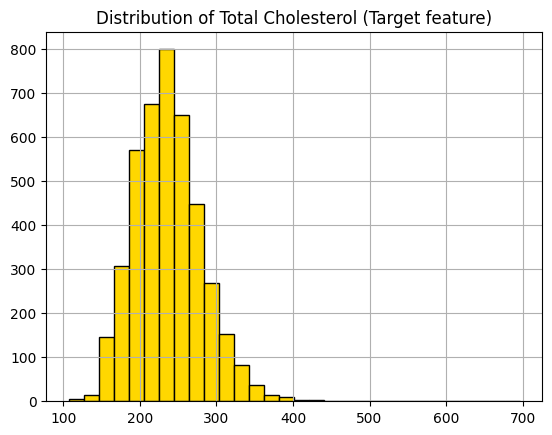

In [5]:
# Visualize features distribution
external_data['totChol'].hist(
    #figsize=(12, 10), 
    color='gold',
    edgecolor='black',
    bins=30
)
plt.title("Distribution of Total Cholesterol (Target feature)")
plt.show()

#### - Numeric features

In [5]:
continuous_num_feat = external_data.drop(list(unique_values.keys()), axis=1)
continuous_num_feat_ = continuous_num_feat.drop(['totChol'], axis=1)

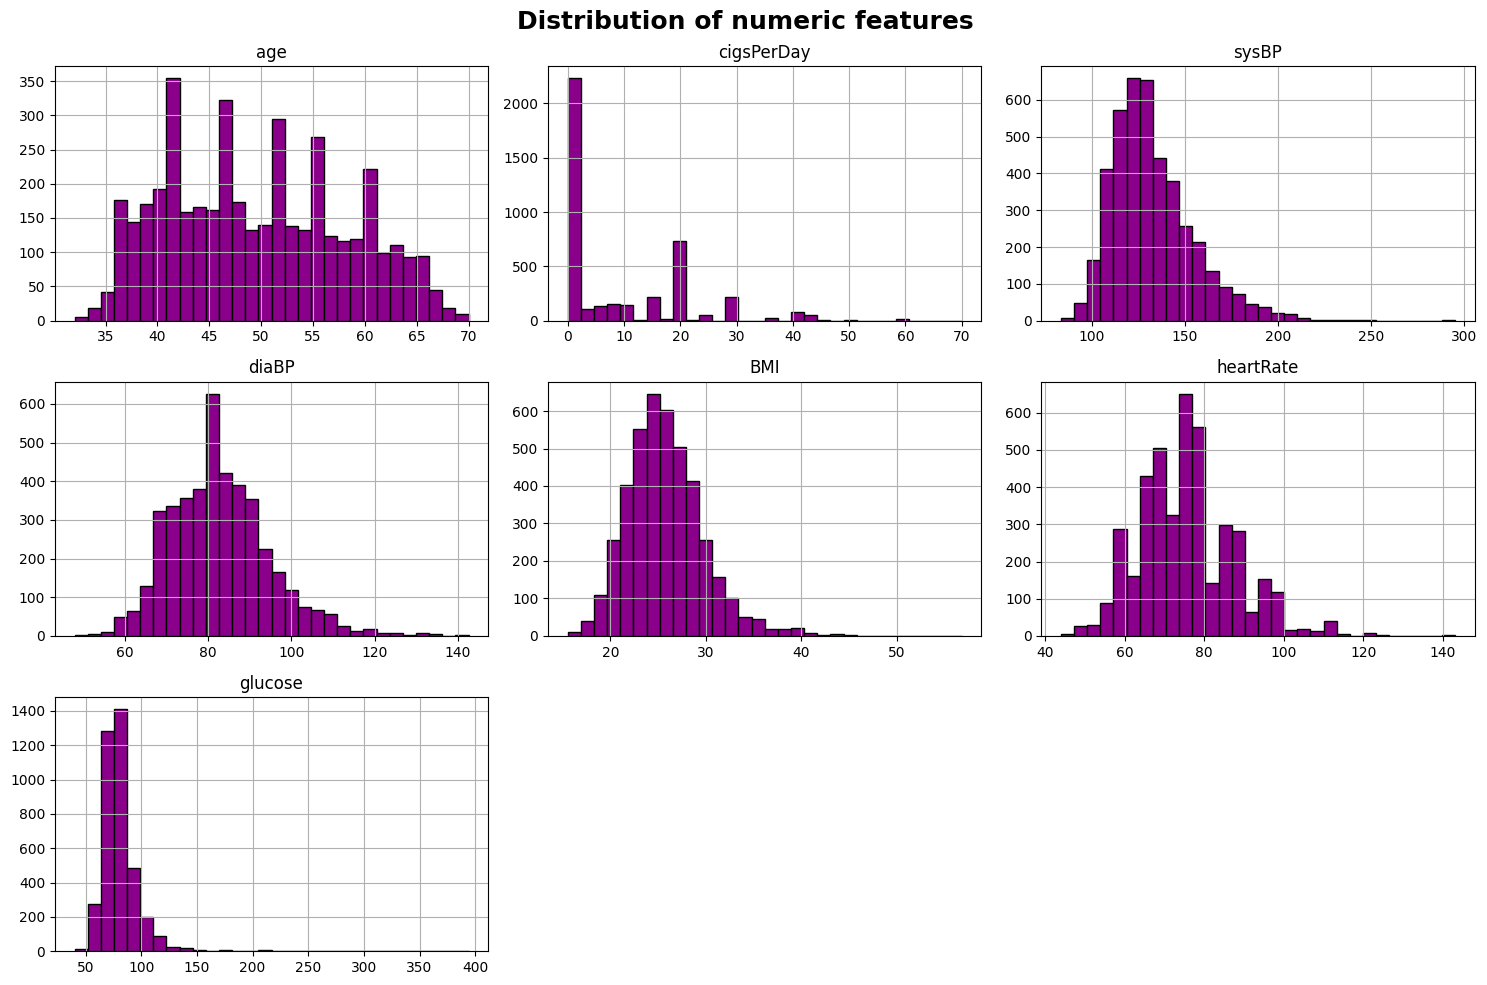

In [15]:
# Visualize features distribution
external_data[continuous_num_feat_.columns].hist(
    figsize=(15, 10), 
    color='darkmagenta',
    edgecolor='black',
    bins=30
)
plt.suptitle("Distribution of numeric features", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

#### - Categorical features

In [6]:
# Get object categorical features 
cat_feat_cols = list(unique_values.keys())
# Print each column's value counts
for f in cat_feat_cols:
    print(external_data[f].value_counts())
    print(external_data[f].value_counts(normalize=True))
    print(20*"---")

male
0    2420
1    1820
Name: count, dtype: int64
male
0    0.570755
1    0.429245
Name: proportion, dtype: float64
------------------------------------------------------------
education
1.0    1720
2.0    1253
3.0     689
4.0     473
Name: count, dtype: int64
education
1.0    0.415961
2.0    0.303023
3.0    0.166626
4.0    0.114389
Name: proportion, dtype: float64
------------------------------------------------------------
currentSmoker
0    2145
1    2095
Name: count, dtype: int64
currentSmoker
0    0.505896
1    0.494104
Name: proportion, dtype: float64
------------------------------------------------------------
BPMeds
0.0    4063
1.0     124
Name: count, dtype: int64
BPMeds
0.0    0.970385
1.0    0.029615
Name: proportion, dtype: float64
------------------------------------------------------------
prevalentStroke
0    4215
1      25
Name: count, dtype: int64
prevalentStroke
0    0.994104
1    0.005896
Name: proportion, dtype: float64
---------------------------------------------

In [7]:
cat_feats = external_data[cat_feat_cols]

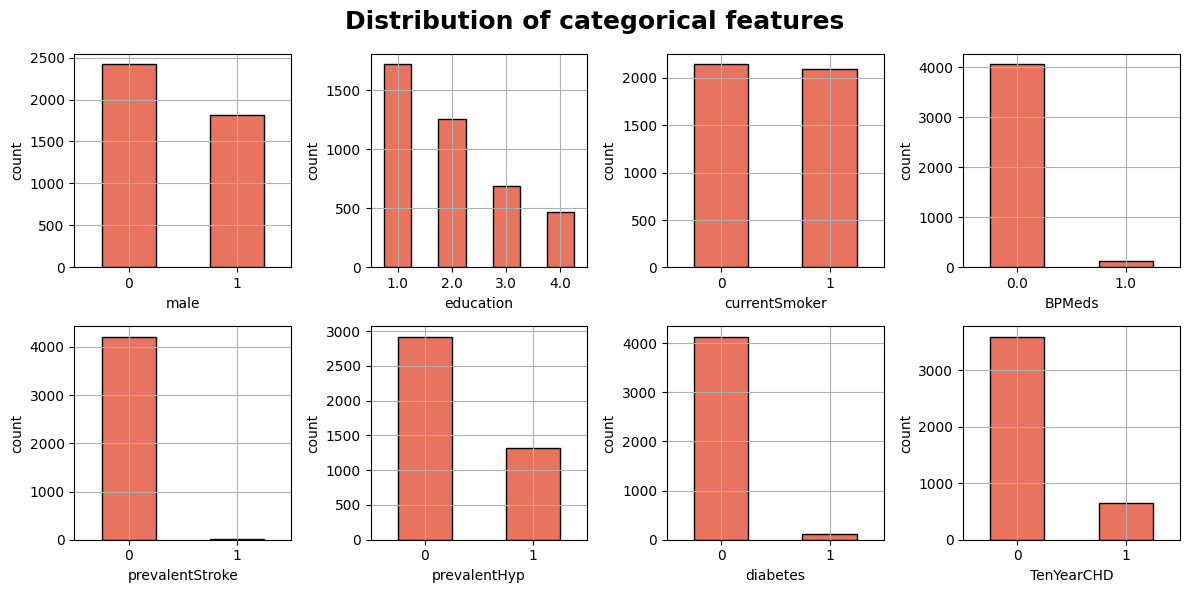

In [10]:
# Create figure and its size/shape
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Flatten axes array for easy looping
axes = axes.flatten()

# Loop through the dataframe and get (index, column)
for i, col in enumerate(cat_feats):
    # Adjust the plot
    sns.countplot(x=col, data=cat_feats, ax=axes[i], width=0.5,
                   color='tomato', edgecolor='black')
    # Add grids
    axes[i].grid()

# If there are empty subplots, remove them
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of categorical features", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

### 4) Check Boxplots (Num features)

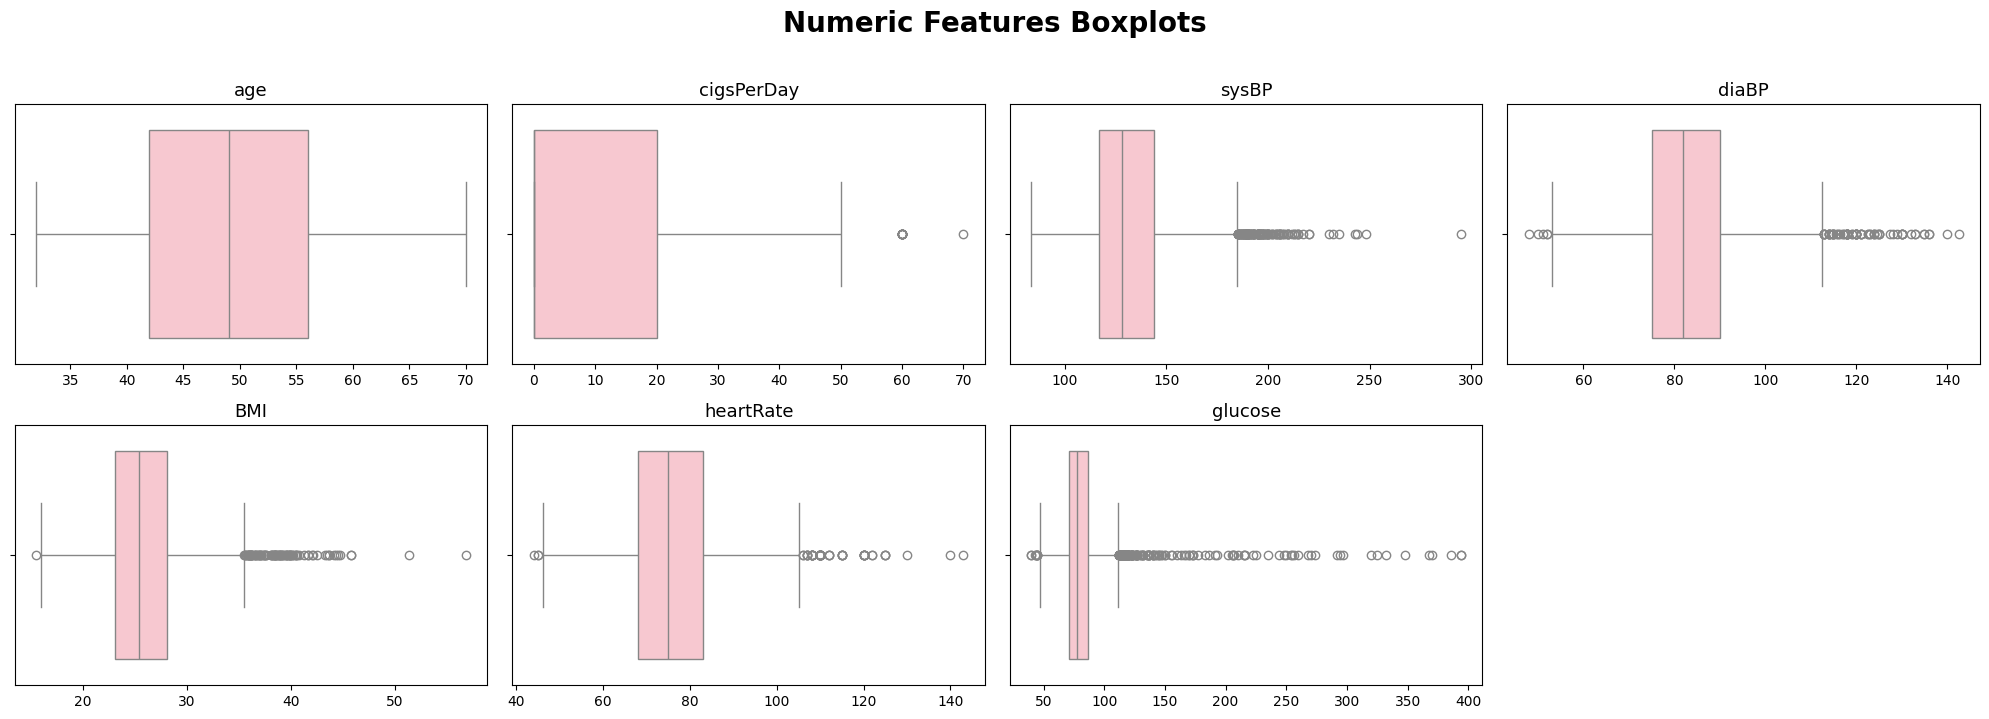

In [68]:
def boxplot(train, color="pink", title="Numeric Features Boxplots"):
    # Figure
    fig, axes = plt.subplots(2, 4, figsize=(20, 7))
    axes = axes.flatten()
    # Visualize
    for i, col in enumerate(train):
        sns.boxplot(data=train, x=col, ax=axes[i], color=color)
        axes[i].set_title(col, fontsize=13)
        axes[i].set_xlabel("")  # Remove x-labels for clean look
    
    # If there are empty subplots, remove them
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(title, fontsize=20, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

boxplot(continuous_num_feat)


### 5) Check Pairplots (Num features)

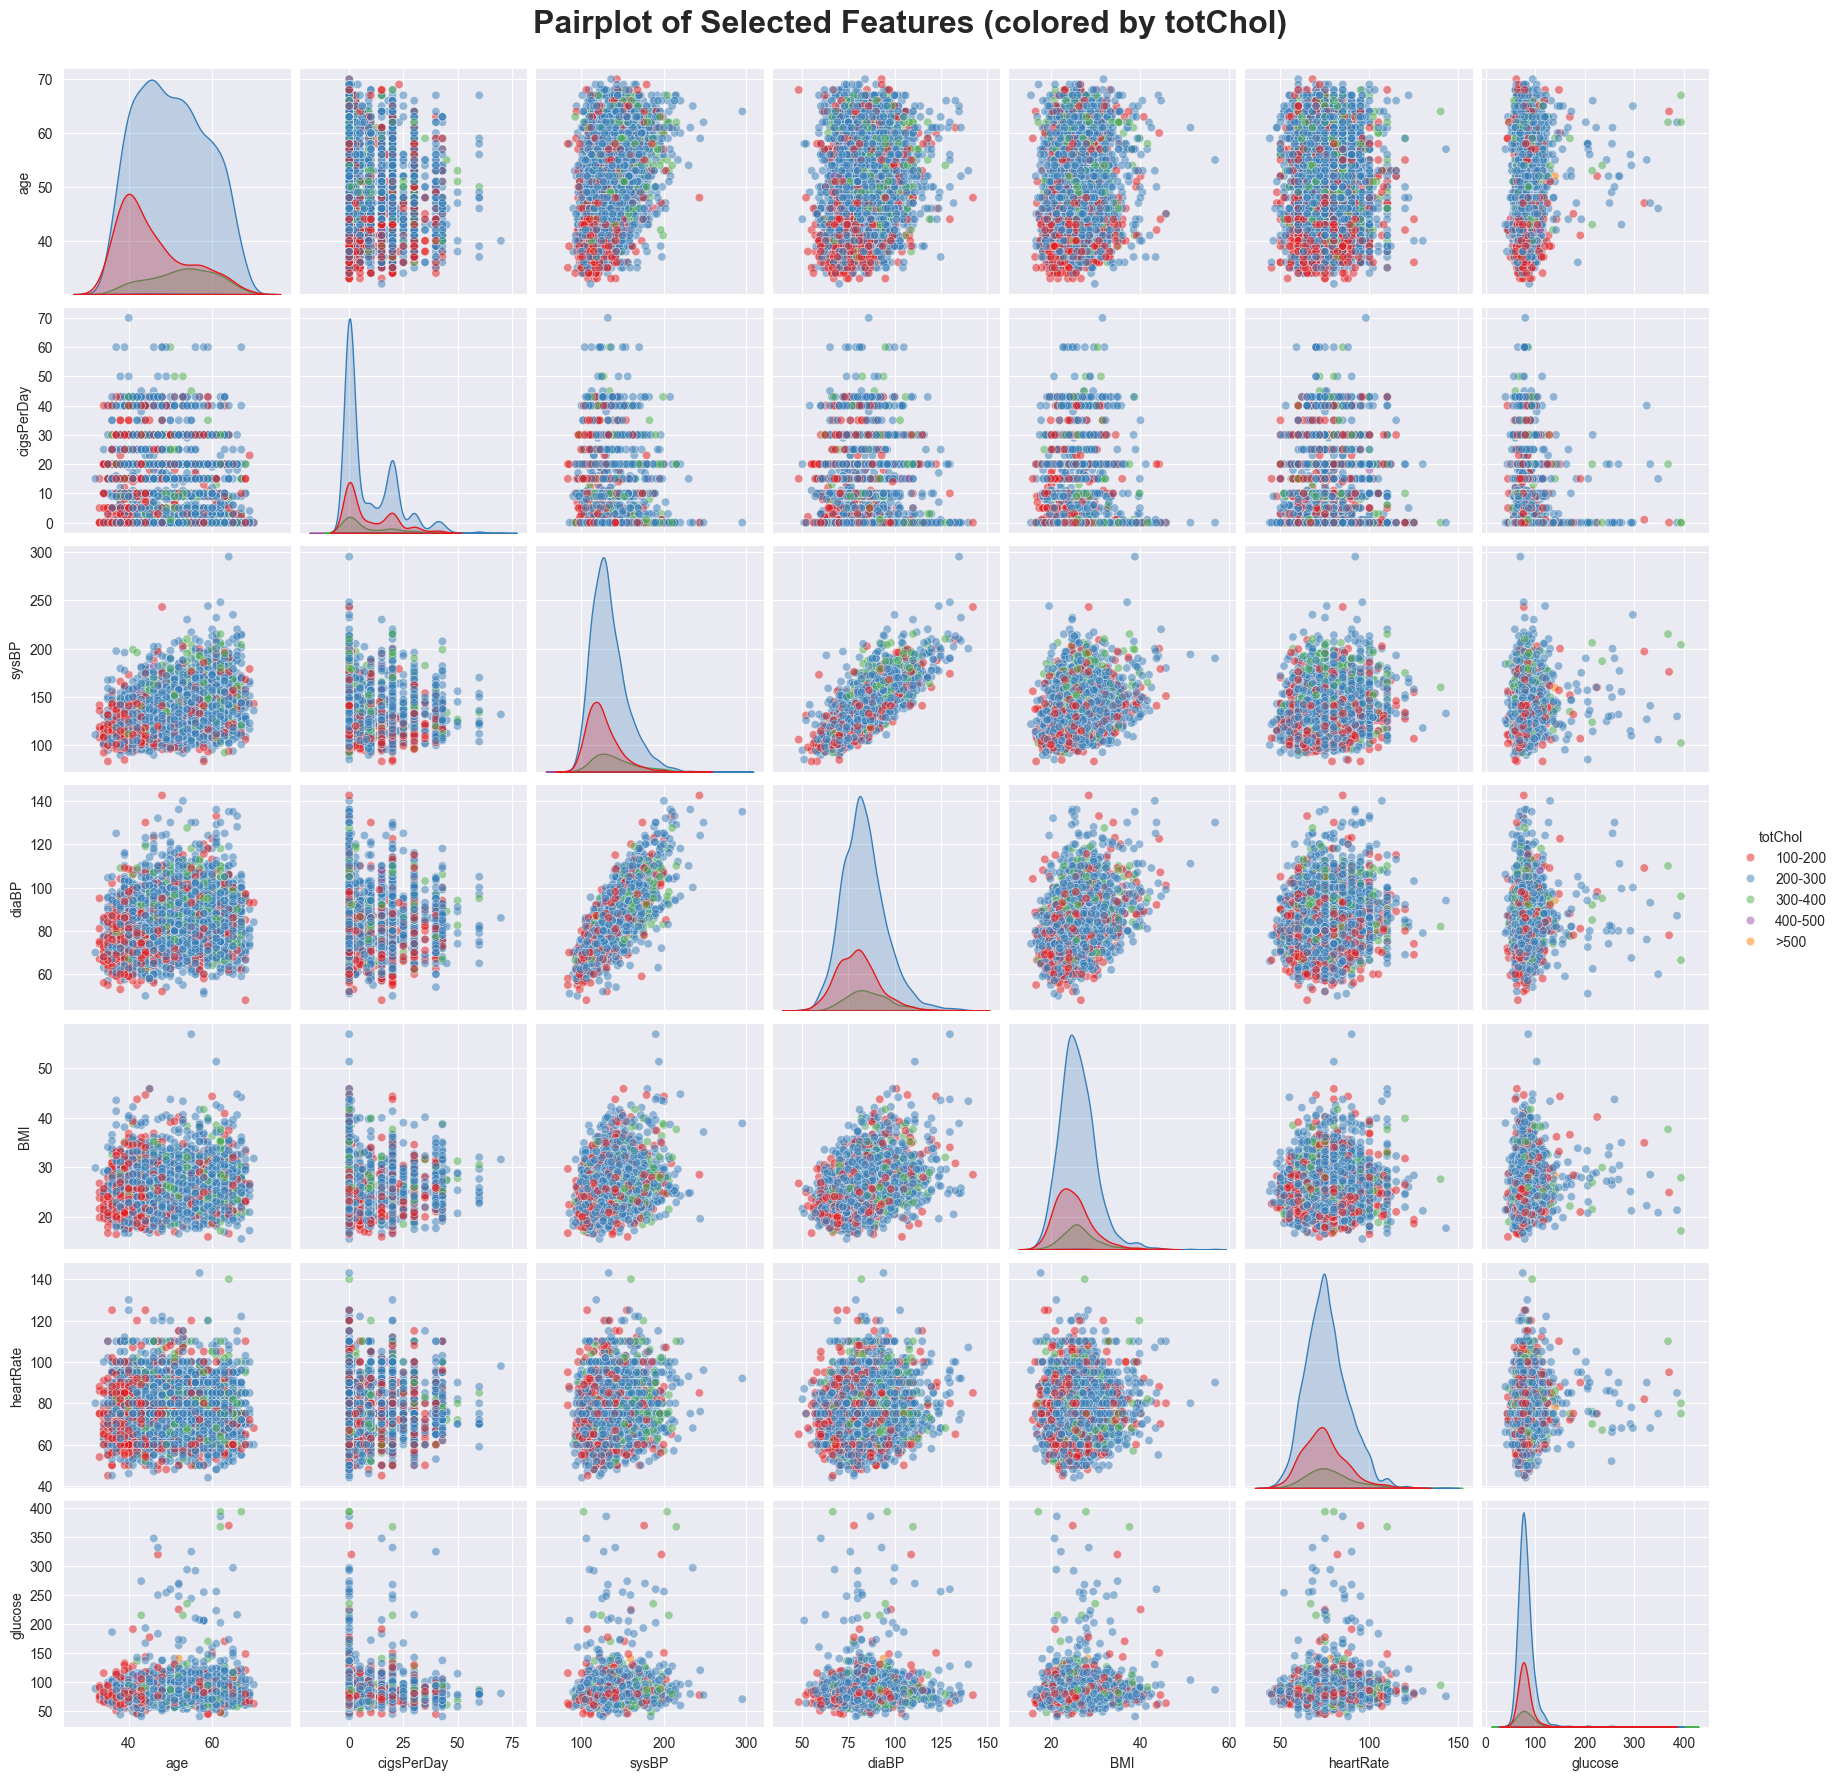

In [ ]:
# Make a copy of external data
ext_data_copy = external_data.copy()
# Categorize `totChol` into 5 categories
ext_data_copy['totChol'] = pd.cut(ext_data_copy['totChol'], bins=[100, 200, 300, 400, 500, 600],
                            labels=['100-200', '200-300', '300-400', '400-500', '>500'])

# Features + the target
selected = continuous_num_feat.columns.tolist() + ['totChol']

# Visualize pairplots
sns.set_style("darkgrid")
sns.pairplot(
    ext_data_copy[selected],
    hue="totChol",
    palette="Set1",
    plot_kws={'alpha': 0.5},
    diag_kind="kde"
)

plt.suptitle("Pairplot of Selected Features (colored by totChol)",
              fontsize=23, fontweight="bold", y=1.02)
plt.show()


### 6) Counts of unlikely values

In [10]:
# Based on the inspection and min/max values, we need to count following features

#--totChol--
print('totChol:')
print(f"Counts of (< 80): {(continuous_num_feat['totChol'] <= 80).sum()}",
        f"\nCounts of (> 500): {(continuous_num_feat['totChol'] >= 500).sum()}\n{20*'--'}")

#--sysBP--
print('sysBP:')
print(f"Counts of (< 80): {(continuous_num_feat['sysBP'] <= 80).sum()}",
        f"\nCounts of (> 250): {(continuous_num_feat['sysBP'] >= 250).sum()}\n{20*'--'}")


#--diaBP--
print('diaBP:')
print(f"Counts of (< 40): {(continuous_num_feat['diaBP'] <= 40).sum()}",
        f"\nCounts of (> 140): {(continuous_num_feat['diaBP'] >= 140).sum()}")



totChol:
Counts of (< 80): 0 
Counts of (> 500): 2
----------------------------------------
sysBP:
Counts of (< 80): 0 
Counts of (> 250): 1
----------------------------------------
diaBP:
Counts of (< 40): 0 
Counts of (> 140): 2


### 7) Check skewness and outliers of numerical features


**Threshold of skewness:**

- |skew| < 0.5 →  Almost symmetric → leave it as is

- 0.5 ≤ |skew| < 1 →  Moderate skew → consider transforming (if it matters for your model)

- |skew| ≥ 1 →  High skew → strongly consider transformation

In [5]:
skewness_detector(continuous_num_feat)

,Feature,Skewness,Skewness_Exceeding_Threshold
0,glucose,6.214948,True
1,cigsPerDay,1.247052,True
2,sysBP,1.145285,True
3,BMI,0.982183,False
4,totChol,0.871881,False
5,diaBP,0.713250,False
6,heartRate,0.644372,False
7,age,0.228867,False


In [6]:
outlier_detector(continuous_num_feat)

,Feature,N_outliers,Outlier_pct
0,glucose,188,4.434
1,sysBP,126,2.972
2,BMI,97,2.288
3,diaBP,77,1.816
4,heartRate,76,1.792
5,totChol,56,1.321
6,cigsPerDay,12,0.283
7,age,0,0.000


### 8) Check correlations of features and classes
- Numeric ↔ Numeric Correlations
- Categorical ↔ Categorical Correlations
- Categorical ↔ Numeric Correlations
- Feature ↔ Target Correlations
    - Continuous Numeric features ↔ Target
    - Categorical features ↔ Target

##### - Drop nans just for a quick correlation check

In [8]:
# Drop nans
external_data_nans_dropped = external_data.copy().dropna()
# Check
check_text = f"""Total rows dropped: {external_data.shape[0] - external_data_nans_dropped.shape[0]}"""
print(check_text)

Total rows dropped: 582


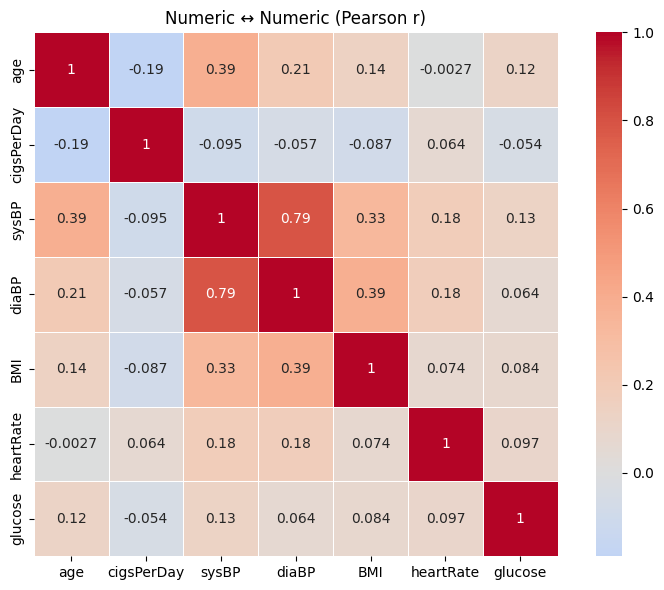

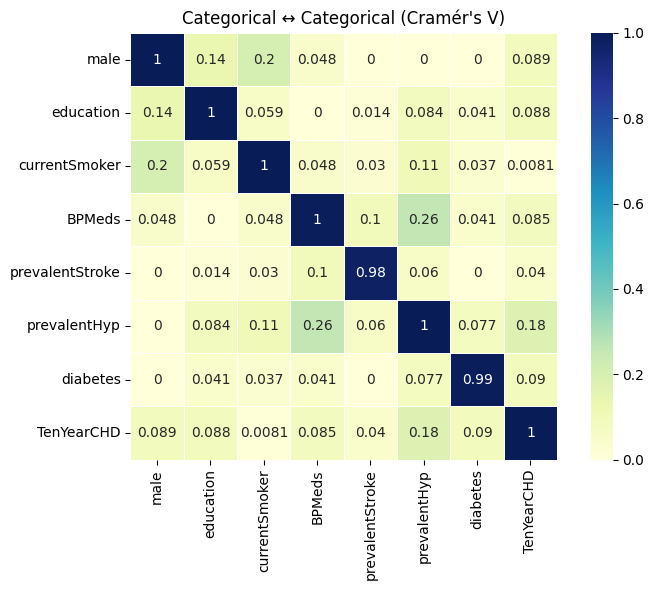

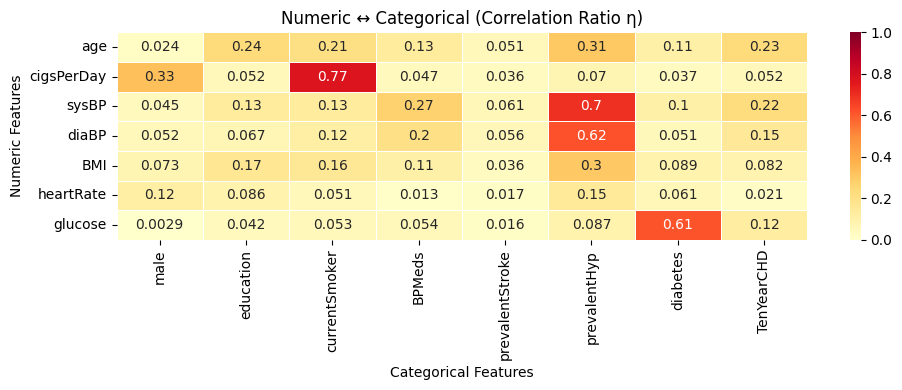

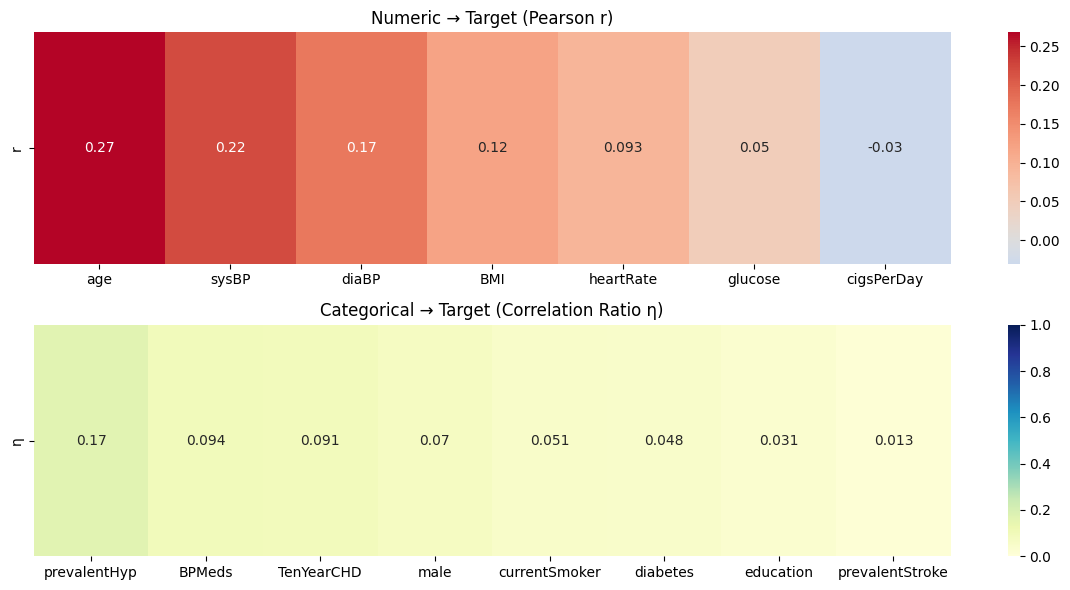

In [9]:
# Get columns name as lists
numeric_features = continuous_num_feat_.columns.tolist()
categorical_features = cat_feats.columns.tolist()

analyzer = CorrelationAnalyzer(
    data=external_data_nans_dropped,
    target_type='numeric',
    num_cols=numeric_features,
    cat_cols=categorical_features,
    target_col='totChol'
)

analyzer.plot_all()
all_results = analyzer.get_correlation_results()

### 9) Split the dataset into train and test sets

In [9]:
from sklearn.model_selection import train_test_split

# Keep 15% as final test set
train_set, test_set = train_test_split(external_data, test_size=0.15,
                                       random_state=42, stratify=external_data['TenYearCHD'])

train_set.to_csv(DATA_DIR / "framingham_train_set.csv", index=False)
test_set.to_csv(DATA_DIR / "framingham_test_set.csv", index=False)

print(f"Train set: {len(train_set)}  |  Test set: {len(test_set)}")

Train set: 3604  |  Test set: 636
